In [2]:
library(edgeR)
library(ggplot2)
library(ggrepel)
library(reshape2)

In [3]:
data = read.table("all_atac_peaks_merged_featurecounts.txt", header=1)
peak.info = data[,1:6]
data = data[,7:dim(data)[2]]
rownames(data) = peak.info$Geneid
colnames(data) = gsub("results.bowtie2_bam.", "", 
                   gsub("_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam", "", colnames(data)))
head(data)

,...bowtie2_bam.HU_A_rep1,...bowtie2_bam.HU_A_rep2,...bowtie2_bam.HU_F_rep1,...bowtie2_bam.HU_F_rep2,...bowtie2_bam.Unt_A_rep1,...bowtie2_bam.Unt_A_rep2,...bowtie2_bam.Unt_F_rep1,...bowtie2_bam.Unt_F_rep2
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
atac_peak1,14,46.0,15,19.0,19.0,48,25.0,12
atac_peak2,12,10.5,18,8.5,9.5,24,6.5,7
atac_peak3,16,7.5,12,7.5,3.5,11,4.5,9
atac_peak4,339,476.0,271,258.0,234.0,617,285.0,203
atac_peak5,48,72.0,41,41.0,16.0,104,27.0,60
atac_peak6,106,177.0,107,93.0,65.0,152,86.0,86


[1] 154753      8
[1] "ua" "ua" "uf" "uf" "ha" "ha" "hf" "hf"


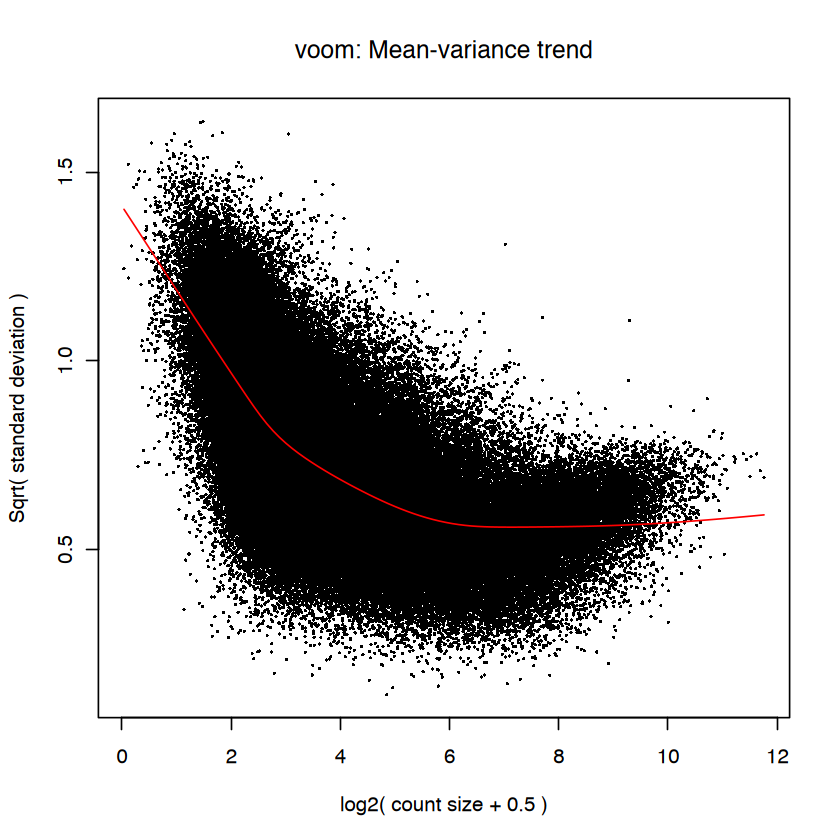

In [4]:
d0 <- DGEList(data)
d0 <- calcNormFactors(d0, method="TMM")
print(dim(d0)) # number of genes left

# conditions for differential peak calling
conds = c("ua", "ua", "uf", "uf", "ha", "ha", "hf", "hf")
print(conds)

# normalize
mm <- model.matrix(~0 + conds)
y <- voom(d0, mm, plot = T)
fit <- lmFit(y, mm)
#head(coef(fit))

In [5]:
# get differentially accessible peaks for each condition
process_res = function(fit, contr) {
    tmp <- contrasts.fit(fit, contr)
    tmp <- eBayes(tmp)
    res <- topTable(tmp, sort.by = "P", n = Inf)
    return(res)
}

In [7]:
hf_vs_uf = process_res(fit, makeContrasts("condshf-condsuf", levels = colnames(coef(fit))))
dim(subset(hf_vs_uf, logFC < -1 & P.Value < 0.05))
dim(subset(hf_vs_uf, logFC > 1 & P.Value < 0.05))

dim(subset(hf_vs_uf, logFC < -1 & adj.P.Val < 0.05))
dim(subset(hf_vs_uf, logFC > 1 & adj.P.Val < 0.05))

[1] 1027    6

[1] 698   6

[1] 0 6

[1] 0 6

In [6]:
uf_vs_ua = process_res(fit, makeContrasts("condsuf-condsua", levels = colnames(coef(fit))))
dim(subset(uf_vs_ua, logFC < -1 & P.Value < 0.05))
dim(subset(uf_vs_ua, logFC > 1 & P.Value < 0.05))

dim(subset(uf_vs_ua, logFC < -1 & adj.P.Val < 0.05))
dim(subset(uf_vs_ua, logFC > 1 & adj.P.Val < 0.05))

[1] 771   6

[1] 3199    6

[1] 0 6

[1] 0 6

In [36]:
subset(peak.info, Geneid=="atac_peak140803")

,Geneid,Chr,Start,End,Strand,Length
,<chr>,<chr>,<int>,<int>,<chr>,<int>
140803,atac_peak140803,chr8,111758732,111759092,+,361


In [31]:
subset(uf_vs_ua, logFC > 1 & P.Value < 0.05)

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
atac_peak79434,3.448585,-0.56897608,4.299476,0.0004520013,0.9999526,-4.517250
atac_peak61676,2.692023,-0.16706321,4.129617,0.0006563147,0.9999526,-4.505687
atac_peak123239,2.953304,0.01162280,4.043036,0.0007940875,0.9999526,-4.508806
atac_peak140803,2.592152,-0.15019121,4.026545,0.0008234594,0.9999526,-4.497511
atac_peak108726,2.833632,-0.43897175,3.992592,0.0008874182,0.9999526,-4.506737
atac_peak103477,3.249655,-0.52264521,3.933560,0.0010107341,0.9999526,-4.530709
atac_peak138874,2.482600,0.14570462,3.928277,0.0010225737,0.9999526,-4.484204
atac_peak132266,2.422578,-0.29656062,3.880389,0.0011364639,0.9999526,-4.503902
atac_peak111650,2.732495,0.03343071,3.864368,0.0011773377,0.9999526,-4.511436


In [27]:
hf_vs_ha = process_res(fit, makeContrasts("condshf-condsha", levels = colnames(coef(fit))))
dim(subset(hf_vs_ha, logFC < -1 & P.Value < 0.05))
dim(subset(hf_vs_ha, logFC > 1 & P.Value < 0.05))

dim(subset(hf_vs_ha, logFC < -1 & adj.P.Val < 0.05))
dim(subset(hf_vs_ha, logFC > 1 & adj.P.Val < 0.05))

[1] 589   6

[1] 1034    6

[1] 0 6

[1] 0 6

In [28]:
ha_vs_ua = process_res(fit, makeContrasts("condsha-condsua", levels = colnames(coef(fit))))
dim(subset(ha_vs_ua, logFC < -1 & P.Value < 0.05))
dim(subset(ha_vs_ua, logFC > 1 & P.Value < 0.05))

dim(subset(ha_vs_ua, logFC < -1 & adj.P.Val < 0.05))
dim(subset(ha_vs_ua, logFC > 1 & adj.P.Val < 0.05))

[1] 1213    6

[1] 461   6

[1] 0 6

[1] 0 6

In [37]:
dim(uf_vs_ua)

[1] 154753      6

In [40]:
tobias = read.table("bindetect_results.txt", header=1, row.names = 2)
head(tobias)

,output_prefix,motif_id,cluster,total_tfbs,Unt_A_mean_score,Unt_A_bound,Unt_F_mean_score,Unt_F_bound,HU_A_mean_score,HU_A_bound,⋯,Unt_A_HU_A_change,Unt_A_HU_A_pvalue,Unt_A_HU_F_change,Unt_A_HU_F_pvalue,Unt_F_HU_A_change,Unt_F_HU_A_pvalue,Unt_F_HU_F_change,Unt_F_HU_F_pvalue,HU_A_HU_F_change,HU_A_HU_F_pvalue
,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FOSL2::JUND,FOSL2JUND_MA1144.1,MA1144.1,C_Smad2::Smad3,20227,0.36491,5704,0.34073,5211,0.36046,5543,⋯,0.07129,1.29556e-98,0.30884,2.25547e-158,-0.17610,1.81278e-134,0.12126,3.90218e-118,0.28516,2.96424e-158
BHLHE41,BHLHE41_MA0636.1,MA0636.1,C_ARNT2,5278,0.70377,2257,0.71359,2251,0.69788,2214,⋯,0.07885,3.23785e-81,0.11336,9.92340e-97,0.06162,8.67108e-71,0.11224,2.64553e-96,0.06144,1.15074e-70
ZBTB7C,ZBTB7C_MA0695.1,MA0695.1,C_ZBTB7B,10562,0.41080,3206,0.42207,3245,0.41431,3200,⋯,-0.01509,5.86182e-26,-0.09530,3.64983e-102,0.05286,8.65289e-76,-0.04347,9.07020e-70,-0.09365,1.98042e-101
SREBF1,SREBF1_MA0595.1,MA0595.1,C_SREBF1,15161,0.36576,3985,0.36463,4013,0.36860,3959,⋯,-0.01641,3.84594e-38,-0.01190,1.97858e-27,-0.03477,1.90069e-67,-0.03212,5.33803e-64,-0.00086,4.20237e-01
Ahr::Arnt,AhrArnt_MA0006.1,MA0006.1,C_Ahr::Arnt,16082,0.50574,5904,0.51706,5969,0.51029,5878,⋯,-0.00767,4.42398e-13,-0.06406,1.34194e-90,0.04536,1.67435e-77,-0.02320,4.07524e-48,-0.06578,9.78298e-92
MAFK,MAFK_MA0496.3,MA0496.3,C_BACH1,31555,0.33277,8099,0.32330,7695,0.33347,7898,⋯,0.01078,8.79731e-34,0.09901,9.80646e-125,-0.07805,2.34273e-119,0.02721,5.56145e-71,0.09997,3.77436e-125


Warning message:
“ggrepel: 689 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 722 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


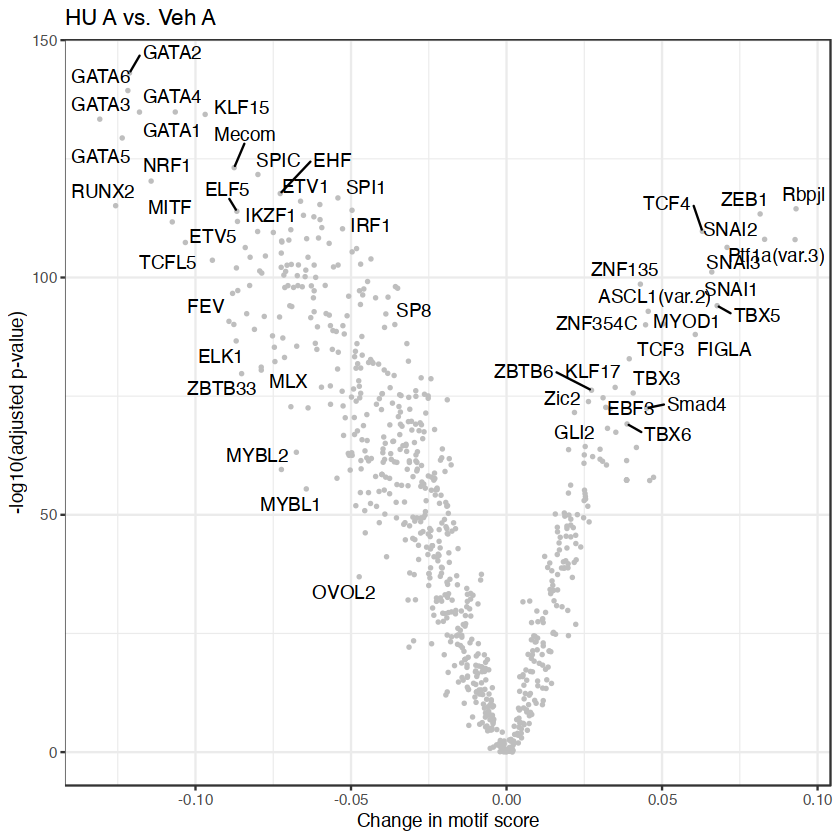

In [67]:
ggplot(tobias, aes(x=-Unt_A_HU_A_change, y=-log10(Unt_A_HU_A_pvalue))) + geom_point(size=0.5, color="gray") +
theme_bw() + geom_text_repel(aes(label=rownames(tobias)), max.overlaps = 15)  + ggtitle("HU A vs. Veh A") +
xlab("Change in motif score") + ylab("-log10(adjusted p-value)")
ggsave("251115_hu_a_vs_unt_a_tobias.pdf", width=4, height=4)

Warning message:
“ggrepel: 616 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 717 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


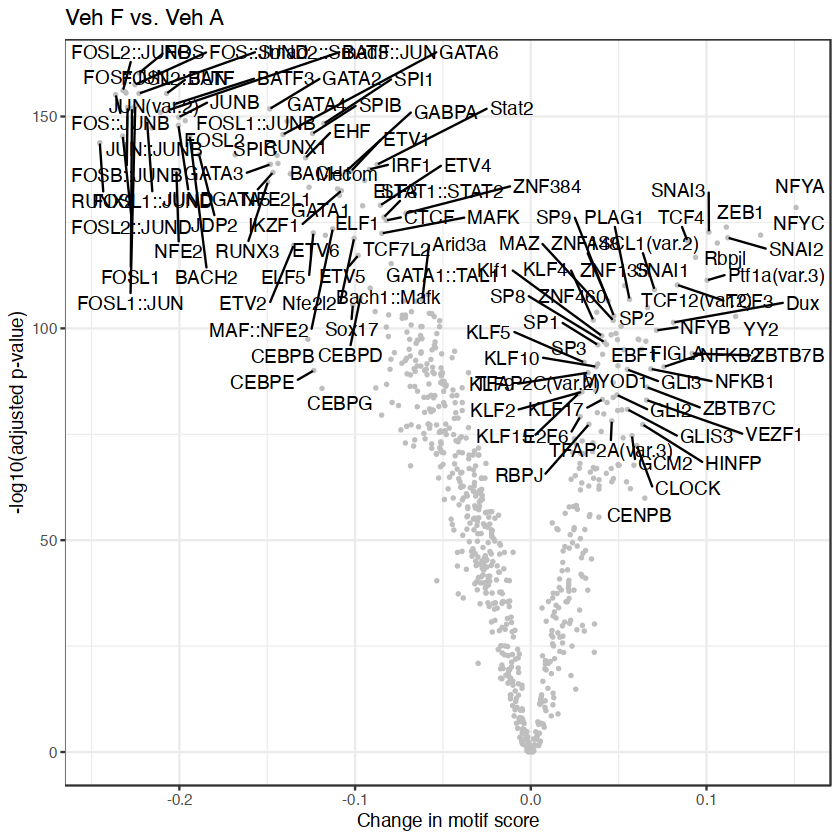

In [66]:
ggplot(tobias, aes(x=-Unt_A_Unt_F_change, y=-log10(Unt_A_Unt_F_pvalue))) + geom_point(size=0.5, color="gray") +
theme_bw() + geom_text_repel(aes(label=rownames(tobias)), max.overlaps = 30) + ggtitle("Veh F vs. Veh A") +
xlab("Change in motif score") + ylab("-log10(adjusted p-value)")
ggsave("251115_unt_f_vs_unt_a_tobias.pdf", width=4, height=4)